In [1]:
import os
import requests
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
from astropy.table import Table
from dask import delayed, compute
from dask.distributed import Client
import warnings

warnings.filterwarnings('ignore')

In [2]:
class SistemaPlanetario:
    def __init__(self, m1, m2, d):
        self.m1 = m1 * 1.989E30  # masa estrella en kg
        self.m2 = m2 * 5.972E24  # masa planeta en kg
        self.mu2 = self.m2 / (self.m1 + self.m2)
        self.mu1 = 1.0 - self.mu2
        self.distanciaPrimarios = d * 1.496E8  # AU -> km

        self.m = 100
        self.n = self.m
        self.a = 0.2
        self.b = self.a
        self.tiempo = 500
        self.M = 1000

        self.estable_x, self.estable_y = [], []
        self.inestable_x, self.inestable_y = [], []
        self.colision_m1x, self.colision_m1y = [], []
        self.colision_m2x, self.colision_m2y = [], []

    def f1(self, t, v):
        x, y, xp, yp = v
        r1p = ((x + self.mu2)**2 + y**2)**(-3/2.)
        r2p = ((x - self.mu1)**2 + y**2)**(-3/2.)
        dv1 = xp + y
        dv2 = yp - x
        dv3 = yp - self.mu1 * (x + self.mu2) * r1p - self.mu2 * (x - self.mu1) * r2p
        dv4 = -xp - self.mu1 * y * r1p - self.mu2 * y * r2p
        return np.array([dv1, dv2, dv3, dv4])

    def RungeKutaS6(self, t0, tn, x0, n):
        t = np.linspace(t0, tn, n + 1)
        m = len(x0)
        x = np.zeros((m, n + 1))
        x[:, 0] = x0
        h = (tn - t0) / n
        TOL = 0.01

        for i in range(1, n + 1):
            k1 = self.f1(t[i-1], x[:, i-1])
            k2 = self.f1(t[i-1] + h*(1/3.), x[:, i-1] + (1/3.)*k1*h)
            k3 = self.f1(t[i-1] + h*(2/3.), x[:, i-1] + (2/3)*k2*h)
            k4 = self.f1(t[i-1] + h*(1/3), x[:, i-1] + (1/12)*k1*h + (1/3)*k2*h - (1/12)*h*k3)
            k5 = self.f1(t[i-1] + h*(5/6.), x[:, i-1] + (25/48.)*k1*h - (55/24.)*k2*h + (35/48.)*k3*h + k4*(15/8.)*h)
            k6 = self.f1(t[i-1] + h*(1/6.), x[:, i-1] + (3/20)*k1*h - (11/24)*k2*h - (1/8)*k3*h + (1/2)*k4*h + (1/10)*h*k5)
            k7 = self.f1(t[i], x[:, i-1] - (261/260)*k1*h + (33/13)*k2*h + (43/156)*k3*h - (118/39)*k4*h + (32/195)*k5*h + (80/39)*k6*h)
            x[:, i] = x[:, i-1] + ((13/200)*k1 + (11/40.)*k3 + (11/40.)*k4 + (4/25)*k5 + (4/25)*k6 + (13/200)*k7)*h

            if x[1, i] < 0:
                j = 1; break
            elif (np.abs(x[0, i] - self.mu2) < TOL and np.abs(x[1, i]) < TOL):
                j = 2; break
            elif (np.abs(x[0, i] - self.mu1) < TOL and np.abs(x[1, i]) < TOL):
                j = 3; break
        else:
            j = 4
        return j, x

    def malla(self, m, n, a, b):
        x = np.linspace(-a, a, n)
        y = np.linspace(-b, b, m)
        xx, yy = np.meshgrid(x, y)
        return np.c_[xx.ravel(), yy.ravel()]

    def simular(self, client=None, chunk_size=100):
        points = self.malla(self.m, self.n, self.a, self.b)
        
        @delayed
        def simular_lote(lote):
            resultados_lote = []
            for point in lote:
                x0 = 0.5 - self.mu2 + point[0]
                y0 = (3**0.5) * 0.5 + point[1]
                j, _ = self.RungeKutaS6(0, self.tiempo, [x0, y0, -y0, x0], self.M)
                resultados_lote.append((j, x0, y0))
            return resultados_lote

        lotes = [points[i:i+chunk_size] for i in range(0, len(points), chunk_size)]
        tareas = [simular_lote(lote) for lote in lotes]
        resultados = client.compute(tareas, sync=True) if client else compute(*tareas)

        for lote in resultados:
            for j, x0, y0 in lote:
                if j == 1: self.inestable_x.append(x0); self.inestable_y.append(y0)
                elif j == 2: self.colision_m1x.append(x0); self.colision_m1y.append(y0)
                elif j == 3: self.colision_m2x.append(x0); self.colision_m2y.append(y0)
                else: self.estable_x.append(x0); self.estable_y.append(y0)

    def guardar_resultados(self, directorio, nombre="zonas", graficar=True):
        os.makedirs(directorio, exist_ok=True)

        Table([self.estable_x, self.estable_y], names=('x', 'y')).write(
            os.path.join(directorio, f"{nombre}_estables.txt"),
            format='ascii.commented_header', overwrite=True)
        Table([self.inestable_x, self.inestable_y], names=('x', 'y')).write(
            os.path.join(directorio, f"{nombre}_inestables.txt"),
            format='ascii.commented_header', overwrite=True)
        Table([self.colision_m1x, self.colision_m1y], names=('x', 'y')).write(
            os.path.join(directorio, f"{nombre}_colision_m1.txt"),
            format='ascii.commented_header', overwrite=True)
        Table([self.colision_m2x, self.colision_m2y], names=('x', 'y')).write(
            os.path.join(directorio, f"{nombre}_colision_m2.txt"),
            format='ascii.commented_header', overwrite=True)

        estable_x = len(self.estable_x)
        inestable_x = len(self.inestable_x)
        colision_m1 = len(self.colision_m1x)
        colision_m2 = len(self.colision_m2x)

        deltaA = (2 * self.a) / self.n
        deltaB = (2 * self.b) / self.m
        deltaKmA = deltaA * self.distanciaPrimarios
        deltaKmB = deltaB * self.distanciaPrimarios
        area = deltaKmA * deltaKmB

        area_est = area * estable_x
        area_inest = area * inestable_x
        area_colM1 = area * colision_m1
        area_colM2 = area * colision_m2

        resumen_path = os.path.join(directorio, f"{nombre}_resumen.txt")
        with open(resumen_path, "w", encoding='utf-8') as f:
            f.write("=== Resumen de resultados ===\n")
            f.write(f"Total estables: {estable_x}\n")
            f.write(f"Total inestables: {inestable_x}\n")
            f.write(f"Total colisión m1: {colision_m1}\n")
            f.write(f"Total colisión m2: {colision_m2}\n\n")
            f.write("=== Areas en km2 ===\n")
            f.write("Area total de la grilla: {:.2e} km2\n".format(area))
            f.write("Area estable: {:.2e} km2\n".format(area_est))
            f.write("Area inestable: {:.2e} km2\n".format(area_inest))
            f.write("Area de colisión con m1: {:.2e} km2\n".format(area_colM1))
            f.write("Area de colisión con m2: {:.2e} km2\n".format(area_colM2))

        if graficar:
            plt.scatter(self.estable_x, self.estable_y, color='blue', s=10, label='Estables')
            plt.scatter(self.inestable_x, self.inestable_y, color='silver', s=10, label='Inestables')
            plt.scatter(self.colision_m1x, self.colision_m1y, color='green', s=10, label='Colision m1')
            plt.scatter(self.colision_m2x, self.colision_m2y, color='brown', s=10, label='Colision m2')
            plt.scatter(0.5 - self.mu2, np.sqrt(3)/2, marker='v', color='red', label='L4')
            plt.xlabel('x [adim]')
            plt.ylabel('y [adim]')
            plt.legend()
            plt.title(f"Mapa de estabilidad - {nombre}")
            ruta_pdf = os.path.join(directorio, f"{nombre}_mapa_estabilidad.pdf")
            plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
            plt.close()
            
        return area_est

In [14]:
def graficar_histograma_planetas(df_star, tipo_espectral, base_dir):
    """
    Genera un histograma que muestra la cantidad de sistemas encontrados 
    clasificados por su numero de planetas (3, 4, 5, 6, 7).
    """
    conteo_planetas = df_star['sy_pnum'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    
    colores_discretos = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4']
    colores_barras = [colores_discretos[i % len(colores_discretos)] for i in range(len(conteo_planetas))]

    barras = ax.bar(conteo_planetas.index, conteo_planetas.values, color=colores_barras, edgecolor='black', alpha=0.85)

    ax.set_title(f"Distribucion de Sistemas Planetarios - Estrellas Tipo {tipo_espectral}", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Cantidad de Planetas en el Sistema", fontsize=12, fontweight='bold')
    ax.set_ylabel("Numero de Sistemas", fontsize=12, fontweight='bold')

    ax.set_xticks(conteo_planetas.index)

    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2., altura + 0.1,
                f'{int(altura)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    
    # Guardado doble en PNG y PDF
    ruta_png = os.path.join(base_dir, f"Histograma_Planetas_Tipo_{tipo_espectral}.png")
    ruta_pdf = os.path.join(base_dir, f"Histograma_Planetas_Tipo_{tipo_espectral}.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    
    plt.show()  
    plt.close()

    print(f"Histograma guardado en PNG y PDF en: {base_dir}")

In [15]:
def graficar_analisis_concentracion(lista_a, lista_areas, lista_pnum, tipo_espectral, base_dir):
    a_total = np.array(lista_a, dtype=float)
    areas = np.array(lista_areas, dtype=float)
    pnum_total = np.array(lista_pnum, dtype=int)
    
    validos = np.isfinite(a_total) & np.isfinite(areas) & (a_total > 0) & (areas > 0)
    a_total = a_total[validos]
    areas = areas[validos]
    pnum_total = pnum_total[validos]
    
    if len(a_total) < 2:
        print(f"No hay suficientes datos para hacer el KDE del Tipo {tipo_espectral}.")
        return

    log_a = np.log10(a_total)
    kde = gaussian_kde(log_a)
    x_eval = np.linspace(log_a.min(), log_a.max(), 1000)
    y_eval = kde(x_eval)

    idx_max = np.argmax(y_eval)
    log_a_pico = x_eval[idx_max]
    a_pico = 10**log_a_pico

    umbral = y_eval.max() * 0.5
    indices_rango = np.where(y_eval > umbral)[0]
    log_a_min, log_a_max = x_eval[indices_rango[0]], x_eval[indices_rango[-1]]
    a_min_rango, a_max_rango = 10**log_a_min, 10**log_a_max

    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    texto_rango = f'Region de Concentracion: {a_min_rango:.2f} - {a_max_rango:.2f} UA'
    ax1.axvspan(a_min_rango, a_max_rango, color='gray', alpha=0.15, label=texto_rango, zorder=0)
    ax1.axvline(a_min_rango, color='black', linestyle='--', linewidth=0.8, alpha=0.4, zorder=1)
    ax1.axvline(a_max_rango, color='black', linestyle='--', linewidth=0.8, alpha=0.4, zorder=1)
    ax1.axvline(a_pico, color='red', linestyle=':', linewidth=1.2, alpha=0.6, label=f'Pico de densidad: {a_pico:.2f} UA', zorder=1)

    colores_discretos = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6']
    valores_unicos_pnum = sorted(np.unique(pnum_total))

    for i, p in enumerate(valores_unicos_pnum):
        mask = (pnum_total == p)
        color_asignado = colores_discretos[i % len(colores_discretos)]
        ax1.plot(a_total[mask], areas[mask], marker='o', color=color_asignado, markersize=10, 
                 linestyle='', alpha=0.8, label=f'Sistemas con {p} planetas', 
                 markeredgecolor='black', zorder=3)

    ax1.set_xscale('log')
    ax1.set_yscale('log')
    
    # Ajuste de margenes para evitar que se corten los puntos en los bordes
    ax1.set_xlim(a_total.min() * 0.5, a_total.max() * 2.0)
    ax1.set_ylim(areas.min() * 0.5, areas.max() * 2.0)

    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1e}')) 

    ax1.set_xlabel("log[a] (UA)", fontsize=12, fontweight='bold')
    ax1.set_ylabel(r"log[Areas Estables] (km$^2$)", fontsize=12, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)

    ax2 = ax1.twinx()
    ax2.set_ylabel(r"$\mu_2 (\times 10^{-6})$", color='black', fontsize=12, fontweight='bold') 
    ax2.set_yscale('log')
    ax2.set_ylim(ax1.get_ylim()) 
    ax2.yaxis.set_major_formatter(plt.NullFormatter()) 

    ax3 = ax1.twiny()
    ax3.set_xlabel(r"$\mu_1$", fontsize=12, fontweight='bold')
    ax3.set_xlim(ax1.get_xlim()) 
    ax3.xaxis.set_major_formatter(plt.NullFormatter()) 

    plt.title(f"Estabilidad vs Distancia - Estrellas Tipo {tipo_espectral} (>= 3 planetas)", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Guardado doble en PNG y PDF
    ruta_png = os.path.join(base_dir, f"Concentracion_Multicolor_{tipo_espectral}.png")
    ruta_pdf = os.path.join(base_dir, f"Concentracion_Multicolor_{tipo_espectral}.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    
    plt.show()  
    plt.close()

    print(f"Grafico KDE guardado en PNG y PDF en: {base_dir}")

In [21]:
def ejecutar_pipeline_completo(tipo_espectral, masa_min, masa_max, client):
    url_base = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    tipo_esp_sql = tipo_espectral.replace("'", "''")
    
    query = f"""
    SELECT hostname AS estrella, sy_pnum, sy_dist, st_spectype, st_teff, st_mass, st_teff_reflink, 
           pl_name, pl_orbsmax, pl_orbper, pl_bmasse, pl_bmassj, pl_msinij
    FROM pscomppars
    WHERE sy_pnum >= 3 AND st_spectype LIKE '%{tipo_esp_sql}%'
      AND (pl_bmassj BETWEEN {masa_min} AND {masa_max} OR pl_msinij BETWEEN {masa_min} AND {masa_max})
    """
    
    print(f"Consultando NASA Exoplanet Archive... (Espectro: {tipo_espectral}, >=3 planetas)")
    respuesta = requests.get(url_base, params={"query": query, "format": "csv"})
    if respuesta.status_code != 200: return
    
    df_completo = pd.read_csv(io.StringIO(respuesta.text))
    if df_completo.empty: 
        print("No se encontraron sistemas que cumplan todos los criterios.")
        return
    
    df_completo['Ano_Ref'] = df_completo['st_teff_reflink'].str.extract(r'(\d{4})').astype(float)
    df_star = df_completo.sort_values(by=['estrella', 'Ano_Ref'], ascending=[True, False]).drop_duplicates(subset=['estrella'], keep='first')

    global base_dir
    base_dir = f"Resultados_Estrellas_{tipo_espectral}_Multi"
    os.makedirs(base_dir, exist_ok=True)
    
    datos_a_AU = []
    datos_areas = []
    datos_pnum = []

    for _, star in df_star.iterrows():
        est_nombre = star['estrella'].replace(" ", "_")
        m_estrella = star['st_mass']
        cantidad_planetas = star['sy_pnum']

        if pd.isna(m_estrella): continue 
            
        print(f"\nSistema: {est_nombre} (Masa: {m_estrella} M_sol, Planetas: {cantidad_planetas})")
        planets = df_completo[df_completo['estrella'] == star['estrella']]
        
        for _, pl in planets.iterrows():
            distancia = pl['pl_orbsmax']
            if pd.isna(distancia): continue
            
            if pd.notna(pl['pl_bmasse']): masa_tierra = pl['pl_bmasse']
            elif pd.notna(pl['pl_bmassj']): masa_tierra = pl['pl_bmassj'] * 317.828
            elif pd.notna(pl['pl_msinij']): masa_tierra = pl['pl_msinij'] * 317.828
            else: continue
                
            path = os.path.join(base_dir, est_nombre, pl['pl_name'].replace(" ", "_"))
            os.makedirs(path, exist_ok=True)
            
            readme_path = os.path.join(path, f"README_{pl['pl_name'].replace(' ', '_')}.txt")
            with open(readme_path, "w", encoding="utf-8") as f:
                f.write(f"SISTEMA: {star['estrella']}\n")
                f.write(f"CANTIDAD DE PLANETAS EN EL SISTEMA: {cantidad_planetas}\n")
                f.write(f"PLANETA: {pl['pl_name']}\n")
                f.write("=" * 40 + "\n")
                f.write(f"Masa de la Estrella (Masas Solares): {m_estrella}\n")
                f.write(f"Temperatura Estrella (K): {star['st_teff']}\n")
                f.write(f"Masa del Planeta (Masas Terrestres): {masa_tierra:.4f}\n")
                f.write(f"Semi-eje mayor de la orbita (UA): {distancia}\n")
                f.write(f"Periodo Orbital (dias): {pl['pl_orbper']}\n")

            print(f"  -> Simulando {pl['pl_name']}...")
            sistema = SistemaPlanetario(m_estrella, masa_tierra, distancia)
            sistema.simular(client=client)
            
            area_calculada = sistema.guardar_resultados(path, nombre=f"{est_nombre}")
            
            datos_a_AU.append(distancia)
            datos_areas.append(area_calculada)
            datos_pnum.append(cantidad_planetas)

    print("\nGenerando analisis estadisticos...")
    
    graficar_histograma_planetas(df_star, tipo_espectral, base_dir)
    graficar_analisis_concentracion(datos_a_AU, datos_areas, datos_pnum, tipo_espectral, base_dir)

In [22]:
if __name__ == "__main__":
    ESPECTRO = "M"
    M_MIN_JUP = 0.0001
    M_MAX_JUP = 13.0
    
    print("Iniciando Dask...")
    cliente_dask = Client(n_workers=4)
    
    ejecutar_pipeline_completo(ESPECTRO, M_MIN_JUP, M_MAX_JUP, client=cliente_dask)
    print("\nINVESTIGACION COMPLETADA EXITOSAMENTE")

Iniciando Dask...
Consultando NASA Exoplanet Archive... (Espectro: M, >=3 planetas)

Sistema: 55_Cnc_B (Masa: 0.26 M_sol, Planetas: 7)
  -> Simulando 55 Cnc B b...
  -> Simulando 55 Cnc B c...

Sistema: AU_Mic (Masa: 0.635 M_sol, Planetas: 4)
  -> Simulando AU Mic c...
  -> Simulando AU Mic b...

Sistema: Barnard's_star (Masa: 0.162 M_sol, Planetas: 4)
  -> Simulando Barnard d...


KeyboardInterrupt: 

Iniciando Dask...
Consultando NASA Exoplanet Archive... (Espectro: G, >=3 planetas)

Sistema: 47_UMa (Masa: 1.06 M_sol, Planetas: 3)
  -> Simulando 47 UMa c...
  -> Simulando 47 UMa b...
  -> Simulando 47 UMa d...

Sistema: 55_Cnc (Masa: 1.015 M_sol, Planetas: 7)
  -> Simulando 55 Cnc f...
  -> Simulando 55 Cnc e...
  -> Simulando 55 Cnc d...
  -> Simulando 55 Cnc b...
  -> Simulando 55 Cnc c...

Sistema: 61_Vir (Masa: 0.942 M_sol, Planetas: 3)
  -> Simulando 61 Vir d...
  -> Simulando 61 Vir b...
  -> Simulando 61 Vir c...

Sistema: CoRoT-7 (Masa: 0.915 M_sol, Planetas: 3)
  -> Simulando CoRoT-7 b...
  -> Simulando CoRoT-7 c...

Sistema: EPIC_249893012 (Masa: 1.05 M_sol, Planetas: 3)
  -> Simulando EPIC 249893012 b...
  -> Simulando EPIC 249893012 c...
  -> Simulando EPIC 249893012 d...

Sistema: HD_10180 (Masa: 1.06 M_sol, Planetas: 6)
  -> Simulando HD 10180 d...
  -> Simulando HD 10180 f...
  -> Simulando HD 10180 h...
  -> Simulando HD 10180 g...
  -> Simulando HD 10180 c...
  -> 

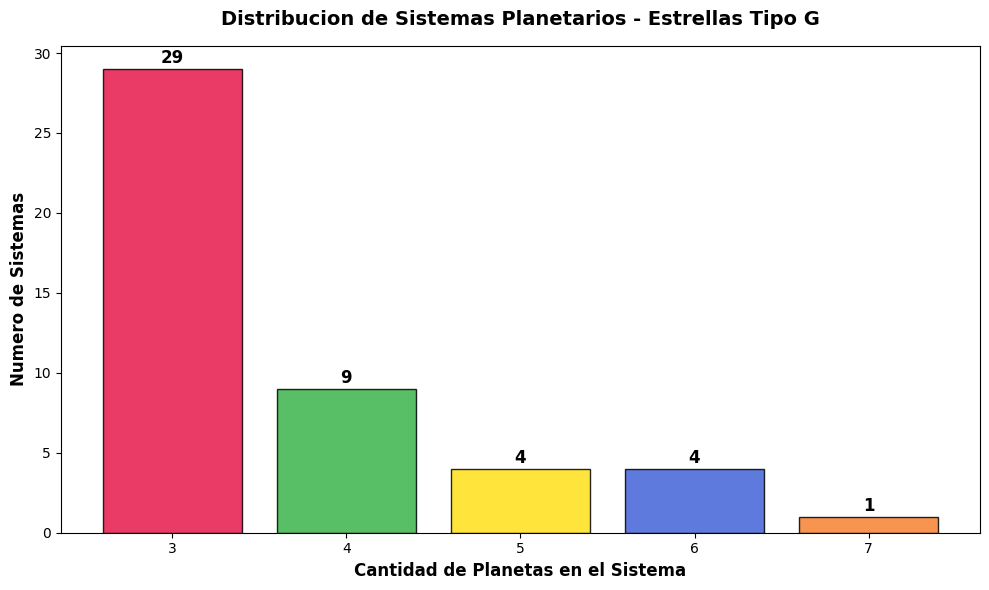

Histograma guardado en PNG y PDF en: Resultados_Estrellas_G_Multi


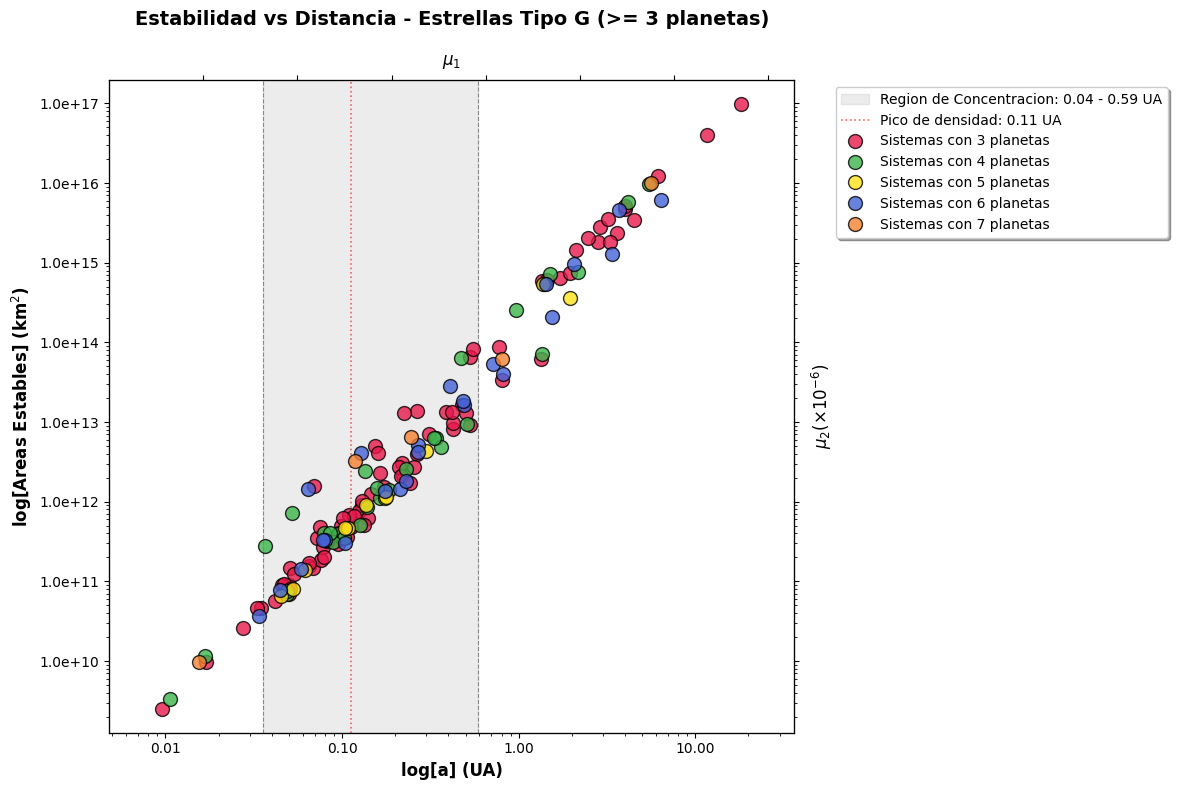

Grafico KDE guardado en PNG y PDF en: Resultados_Estrellas_G_Multi

INVESTIGACION COMPLETADA EXITOSAMENTE


In [18]:
if __name__ == "__main__":
    ESPECTRO = "G"
    M_MIN_JUP = 0.0001
    M_MAX_JUP = 13.0
    
    print("Iniciando Dask...")
    cliente_dask = Client(n_workers=4)
    
    ejecutar_pipeline_completo(ESPECTRO, M_MIN_JUP, M_MAX_JUP, client=cliente_dask)
    print("\nINVESTIGACION COMPLETADA EXITOSAMENTE")